---
title: 'Solutions: Introduction to Gradient Descent'
author: Mark Fuge
format:
    html:
        code-fold: true
        code-summary: "Show Solution Code"
---

These are worked solutions to the exercises at the end of the chapter *Introduction to Gradient Descent*. 

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import check_grad
from scipy.stats import loguniform
from sklearn.datasets import make_regression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.linear_model import SGDRegressor

# --- The chapter's data: a centred line with noise, no intercept ---
X, y, coef = make_regression(n_samples=100, n_features=1, n_informative=1, noise=10, coef=True, random_state=0)
x_arr = X.ravel()
y_arr = y
N = len(y_arr)
wn = (x_arr @ y_arr) / (x_arr @ x_arr)          # normal-equations slope
mean_x2 = np.mean(x_arr ** 2)
curvature = 2 * mean_x2                          # second derivative of the cost in w


def mse(w):
    """Mean squared error of the slope-only model y = w * x."""
    return np.mean((y_arr - w * x_arr) ** 2)


def grad_mse(w):
    """Derivative of the mean squared error with respect to the slope w."""
    return -2 * np.mean((y_arr - w * x_arr) * x_arr)


def gradient_descent(w0, step_size, n_steps):
    """Plain gradient descent on the slope problem; returns every iterate."""
    w_hist = np.zeros(n_steps + 1)
    w_hist[0] = w0
    for t in range(n_steps):
        w_hist[t + 1] = w_hist[t] - step_size * grad_mse(w_hist[t])
    return w_hist


def gradient_descent_momentum(w0, step_size, beta, n_steps):
    """Heavy-ball gradient descent on the slope problem; returns every iterate."""
    w_hist = np.zeros(n_steps + 1)
    w_hist[0] = w0
    velocity = 0.0
    for t in range(n_steps):
        velocity = beta * velocity + grad_mse(w_hist[t])
        w_hist[t + 1] = w_hist[t] - step_size * velocity
    return w_hist


print(f"Normal-equations slope wn = {wn:.4f}, mean of x^2 = {mean_x2:.4f}, curvature lambda = {curvature:.4f}")

Normal-equations slope wn = 42.5717, mean of x^2 = 1.0194, curvature lambda = 2.0388


### Exercise 1: Gradients you will meet again

Every derivation below uses the same two moves as the chapter: the chain rule on a square (bring down a 2, multiply by the derivative of the inside), and the fact that a sum's derivative is the sum of the derivatives.

**(a) Squared error with an intercept.** With residual $r_i = y_i - a x_i - b$,
$$
\frac{\partial J}{\partial a} = -\frac{2}{N}\sum_i r_i\, x_i, \qquad
\frac{\partial J}{\partial b} = -\frac{2}{N}\sum_i r_i .
$$
The intercept behaves like a feature that is always equal to 1. In vector form, with $\mathbf{w} = [a, b]$ and $\mathbf{x}_i = [x_i, 1]$, the two lines combine into $\nabla_\mathbf{w} J = -\frac{2}{N}\sum_i r_i\, \mathbf{x}_i$.

**(b) $L_2$ penalty.** $\nabla_\mathbf{w}\, \alpha \sum_j w_j^2 = 2\alpha\, \mathbf{w}$. The penalty pulls every weight towards zero with a force proportional to the weight; this is why ridge regression *shrinks* but rarely zeroes anything.

**(c) $L_1$ penalty.** For $w_j \neq 0$, $\partial\, \alpha |w_j| / \partial w_j = \alpha\, \mathrm{sign}(w_j)$, so $\nabla_\mathbf{w} \Omega = \alpha\, \mathrm{sign}(\mathbf{w})$. At $w_j = 0$ the derivative does not exist: the left and right slopes are $-\alpha$ and $+\alpha$. Any value in $[-\alpha, \alpha]$ is a valid *subgradient*, and that is exactly what lets a weight sit at exactly zero: the data gradient only has to be smaller than $\alpha$ in magnitude to be cancelled.

**(d) Huber loss.** $dL/dr = r$ for $|r| \le \delta$ and $\delta\, \mathrm{sign}(r)$ otherwise. The derivative is the squared-error derivative near zero and saturates at $\pm\delta$ far away, which is the whole point: an outlier's pull on the loss is capped at a fixed value.

**(e) Logistic loss.** With $z = y\,\mathbf{w}^T\mathbf{x}$ and $L = \log(1 + e^{-z})$,
$$
\nabla_\mathbf{w} L = \frac{-e^{-z}}{1 + e^{-z}}\; y\,\mathbf{x} = -\big(1 - \sigma(z)\big)\, y\, \mathbf{x},
\qquad \sigma(z) = \frac{1}{1 + e^{-z}} .
$$
A confidently correct example ($z \gg 0$) contributes almost nothing; a misclassified one pulls with weight close to 1.

**(f) Bi-Linear forms.**
For two dot-producted column vectors, if we take the partial derivative with respect to one of them, then the other is treated similarly to a constant, so the basic vector derivative $\frac{\partial}{\partial a} a \mathbf{x} = a$ applies. So $\frac{\partial}{\partial \mathbf{v}} \mathbf{u}^T\mathbf{v} = \mathbf{u}$ and vice versa.

**(g) Matrix forms.**
$$
\nabla_\mathbf{w}\, ||\mathbf{y} - \mathbf{X}\mathbf{w}||_2^2 = -2\,\mathbf{X}^T(\mathbf{y} - \mathbf{X}\mathbf{w}), \qquad
\nabla_\mathbf{w}\, \mathbf{w}^T \mathbf{A} \mathbf{w} = (\mathbf{A} + \mathbf{A}^T)\,\mathbf{w}, \qquad
\frac{\partial}{\partial \mathbf{W}}\, ||\mathbf{Y} - \mathbf{X}\mathbf{W}||_F^2 = -2\,\mathbf{X}^T(\mathbf{Y} - \mathbf{X}\mathbf{W}).
$$
For symmetric $\mathbf{A}$ the middle one is the familiar $2\mathbf{A}\mathbf{w}$. The Frobenius case is just the vector case applied to each column of $\mathbf{W}$ at once. Setting the first gradient to zero gives the normal equations $\mathbf{X}^T\mathbf{X}\mathbf{w} = \mathbf{X}^T\mathbf{y}$ from the start of the chapter.

The cell below checks (a) and (f) numerically.

In [17]:
def finite_difference_gradient(f, w, h=1e-6):
    """Central finite-difference gradient of a scalar function at w."""
    grad = np.zeros_like(w, dtype=float)
    for j in range(w.size):
        step = np.zeros_like(w, dtype=float)
        step[j] = h
        grad[j] = (f(w + step) - f(w - step)) / (2 * h)
    return grad


# (a) with b = 0 reduces to the chapter's grad_mse
def grad_a(a, b):
    """Gradient of the squared error of y = a x + b with respect to (a, b)."""
    residual = y_arr - a * x_arr - b
    return np.array([-2 * np.mean(residual * x_arr), -2 * np.mean(residual)])


print("(a) at a=80, b=0: dJ/da = {:.4f}, chapter grad_mse = {:.4f}".format(grad_a(80, 0)[0], grad_mse(80)))

# (f) on small random matrices
rng = np.random.default_rng(0)
X_small = rng.normal(size=(6, 3))
y_small = rng.normal(size=6)
A_small = rng.normal(size=(3, 3))
w_small = rng.normal(size=3)
analytic_ls = -2 * X_small.T @ (y_small - X_small @ w_small)
numeric_ls = finite_difference_gradient(lambda w: np.sum((y_small - X_small @ w) ** 2), w_small)
analytic_quad = (A_small + A_small.T) @ w_small
numeric_quad = finite_difference_gradient(lambda w: w @ A_small @ w, w_small)
print("(f) least squares: max |analytic - numeric| = {:.2e}".format(np.max(np.abs(analytic_ls - numeric_ls))))
print("(f) quadratic form: max |analytic - numeric| = {:.2e}".format(np.max(np.abs(analytic_quad - numeric_quad))))

(a) at a=80, b=0: dJ/da = 76.3092, chapter grad_mse = 76.3092
(f) least squares: max |analytic - numeric| = 5.11e-10
(f) quadratic form: max |analytic - numeric| = 2.02e-11


### Exercise 2: Chain the pieces together

The gradient of a sum is the sum of the gradients, so `grad_J` is three lines from Exercise 1 added together. The penalties act on the slope $a$ only, so their contribution to the intercept component is zero.

In [18]:
alpha_l2 = 0.1
beta_l1 = 5.0
X_design = np.column_stack([x_arr, np.ones(N)])   # rows x_i = [x_i, 1], parameters w = [a, b]


def J(w):
    """Elastic-net objective: squared error plus L2 and L1 penalties on the slope a only."""
    residual = y_arr - X_design @ w
    a = w[0]
    return np.mean(residual ** 2) + alpha_l2 * a ** 2 + beta_l1 * np.abs(a)


def grad_J(w):
    """Gradient of J, assembled from the pieces of Exercise 1."""
    residual = y_arr - X_design @ w
    grad_data = -2 * X_design.T @ residual / N       # squared error, both components
    grad_l2 = np.array([2 * alpha_l2 * w[0], 0.0])   # L2 penalty on a only
    grad_l1 = np.array([beta_l1 * np.sign(w[0]), 0.0])   # L1 penalty on a only
    return grad_data + grad_l2 + grad_l1


rng = np.random.default_rng(1)
w_test = rng.normal(size=2) * 10 + np.array([30.0, 5.0])     # safely away from a = 0
print("(b) finite-difference check at w = {}: error = {:.2e}".format(np.round(w_test, 2), check_grad(J, grad_J, w_test)))

w_gd = np.array([80.0, 0.0])
for _ in range(200):
    w_gd = w_gd - 0.1 * grad_J(w_gd)
w_no_penalty = np.linalg.lstsq(X_design, y_arr, rcond=None)[0]
print("(c) elastic-net GD:      a = {:.3f}, b = {:.3f}".format(*w_gd))
print("    unpenalized (lstsq): a = {:.3f}, b = {:.3f}   (wn = {:.3f})".format(*w_no_penalty, wn))
for label, a_probe in [("far from the optimum", 80.0), ("at the data optimum wn", wn), ("close to zero", 0.5)]:
    residual = y_arr - (a_probe * x_arr)
    print("(d) {:>22s} (a = {:5.1f}): |data term| = {:6.2f}, |L2 term| = {:5.2f}, |L1 term| = {:5.2f}".format(
        label, a_probe, abs(-2 * np.mean(residual * x_arr)), 2 * alpha_l2 * a_probe, beta_l1))

(b) finite-difference check at w = [33.46 13.22]: error = 8.36e-06
(c) elastic-net GD:      a = 36.559, b = -0.452
    unpenalized (lstsq): a = 42.619, b = -0.814   (wn = 42.572)
(d)   far from the optimum (a =  80.0): |data term| =  76.31, |L2 term| = 16.00, |L1 term| =  5.00
(d) at the data optimum wn (a =  42.6): |data term| =   0.00, |L2 term| =  8.51, |L1 term| =  5.00
(d)          close to zero (a =   0.5): |data term| =  85.78, |L2 term| =  0.10, |L1 term| =  5.00


**(b)** The check must be run away from $a = 0$: the $L_1$ term has no derivative there, and a finite difference straddling zero would report the average of the two one-sided slopes, which disagrees with `np.sign(0) = 0`.

**(c)** Both penalties pull the slope towards zero, so gradient descent settles a little below the unpenalized `wn`: the $L_2$ term by a factor of roughly $1/(1 + \alpha/\overline{x^2})$, the $L_1$ term by a constant offset of $\beta/(2\,\overline{x^2})$.

**(d)** Far from the data optimum the data term dominates: it grows linearly with the distance to $a^*$, and at $a = 80$ it is about fifteen times the $L_1$ term. At the data optimum itself the data term vanishes and only the penalties push, so the final slope settles where the data gradient balances $2\alpha a + \beta$. The difference between the two penalties shows up as $a \to 0$: the $L_2$ gradient $2\alpha a$ shrinks with the weight and disappears, while the $L_1$ gradient stays at $\pm\beta$ no matter how small the weight is. A weight can therefore sit at *exactly* zero under an $L_1$ penalty whenever the data gradient there is smaller than $\beta$, which is how the LASSO produces sparsity; the $L_2$ penalty only ever shrinks a weight towards zero without reaching it.

### Exercise 3: Where does gradient descent end up?

The first step is $x_1 = 4 - 24\alpha$, and where it lands decides which valley gradient descent ends up in. The code runs all four step sizes and plots every iterate.

critical points: x = 0.3927 (f'' = 13.36), x = 1.5309 (f'' = -8.17), x = 3.3263 (f'' = 21.07)
A (alpha = 0.025): x_1 = 3.400, f'(x_1) =    1.66; last four iterates 3.3263, 3.3263, 3.3263, 3.3263
B (alpha = 0.100): x_1 = 1.600, f'(x_1) =   -0.58; last four iterates 3.4830, 3.1050, 3.4830, 3.1050
C (alpha = 0.150): x_1 = 0.400, f'(x_1) =    0.10; last four iterates 0.4185, 0.3685, 0.4185, 0.3685
D (alpha = 0.200): x_1 = -0.800, f'(x_1) =  -45.89; diverges: 4, -0.8, 8.378, -212.5, 7.872e+06


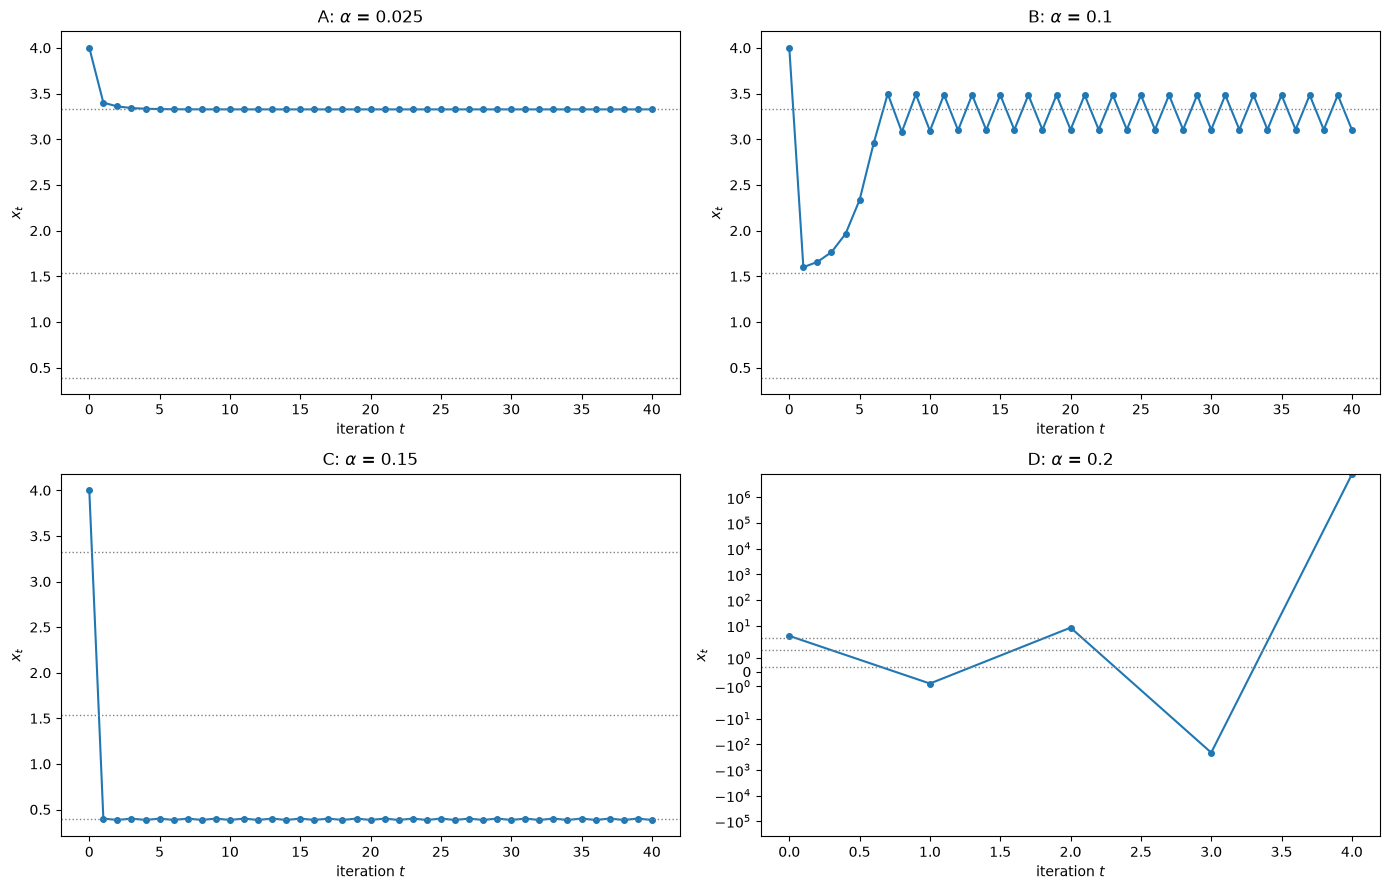

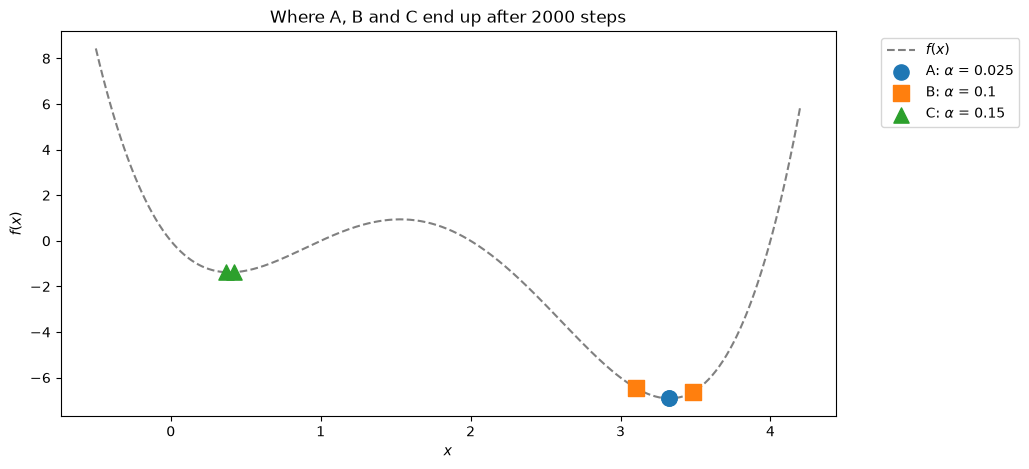

In [19]:
def f_quartic(x):
    """The non-convex quartic from Exercise 3."""
    return x**4 - 7 * x**3 + 14 * x**2 - 8 * x


def df_quartic(x):
    """Derivative of f_quartic."""
    return 4 * x**3 - 21 * x**2 + 28 * x - 8


def gradient_descent_1d(grad, x0, step_size, n_steps, blow_up=1e6):
    """Fixed-step gradient descent on a function of one variable; stops early once |x| exceeds blow_up."""
    x_hist = [x0]
    for _ in range(n_steps):
        x_hist.append(x_hist[-1] - step_size * grad(x_hist[-1]))
        if abs(x_hist[-1]) > blow_up:
            break
    return np.array(x_hist)


critical_points = np.sort(np.roots([4, -21, 28, -8]).real)
curvature_at = 12 * critical_points**2 - 42 * critical_points + 28      # f''(x)
print("critical points: " + ", ".join("x = {:.4f} (f'' = {:.2f})".format(x, c) for x, c in zip(critical_points, curvature_at)))

step_sizes = {"A": 0.025, "B": 0.10, "C": 0.15, "D": 0.2}
runs = {}
for label, step in step_sizes.items():
    runs[label] = gradient_descent_1d(df_quartic, 4.0, step, 2000)
    x_hist = runs[label]
    if abs(x_hist[-1]) > 1e6:
        ending = "diverges: " + ", ".join("{:.4g}".format(x) for x in x_hist[:5])
    else:
        ending = "last four iterates " + ", ".join("{:.4f}".format(x) for x in x_hist[-4:])
    print("{} (alpha = {:.3f}): x_1 = {:.3f}, f'(x_1) = {:7.2f}; {}".format(
        label, step, x_hist[1], df_quartic(x_hist[1]), ending))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (label, step) in zip(axes.ravel(), step_sizes.items()):
    x_hist = runs[label][:41]
    ax.plot(x_hist, 'o-', ms=4)
    for xc in critical_points:
        ax.axhline(xc, color='grey', linestyle=':', linewidth=1)
    if label == "D":
        ax.set_yscale('symlog')
    ax.set_title(r"{}: $\alpha$ = {}".format(label, step))
    ax.set_xlabel('iteration $t$')
    ax.set_ylabel('$x_t$')
plt.tight_layout()
plt.show()

x_plot = np.linspace(-0.5, 4.2, 400)
plt.figure(figsize=(10, 5))
plt.plot(x_plot, f_quartic(x_plot), color='grey', linestyle='--', label='$f(x)$')
for marker, label in zip(['o', 's', '^'], ["A", "B", "C"]):
    tail = runs[label][-2:]            # where each run ends up (two points if it keeps bouncing)
    plt.scatter(tail, f_quartic(tail), marker=marker, s=120, zorder=5,
                label=r"{}: $\alpha$ = {}".format(label, step_sizes[label]))
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.title('Where A, B and C end up after 2000 steps')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**(a)** One step from $x_0 = 4$ moves to $x_1 = 4 - 24\alpha$, and the plots do the rest.

- **A** ($\alpha = 0.025$): $x_1 = 3.4$, already inside the right-hand valley and close to its minimum at $x = 3.326$. The steps are small, so gradient descent walks down to that minimum. This is also the global minimum of $f$.
- **B** ($\alpha = 0.10$): $x_1 = 1.6$, just to the right of the local maximum at $x = 1.531$. There $f'$ is slightly negative, so gradient descent creeps to the right, picks up speed down the slope, and ends in the right-hand valley near $x = 3.33$.
- **C** ($\alpha = 0.15$): $x_1 = 0.4$. The first step jumps clean over the hump and lands almost exactly on the left-hand minimum at $x = 0.393$, so gradient descent stays in that valley. That is a local minimum, well above the global one.
- **D** ($\alpha = 0.2$): $x_1 = -0.8$, far up the steep left wall where $f'(-0.8) \approx -46$. The next step jumps to $x_2 \approx 8.4$, where the gradient is larger still, and every step overshoots by more than the last: gradient descent diverges.

**(b)** A and D behave exactly as predicted, and B and C end up in the predicted valleys. The surprise is that B and C never settle. B keeps bouncing between $x \approx 3.105$ and $x \approx 3.483$ on either side of the right-hand minimum, and C between $x \approx 0.369$ and $x \approx 0.419$ around the left-hand one. This is the same zig-zag you saw in the first Experiment when you made the step size large, except that here it never dies out.

The reason is the curvature at the bottom of each valley, exactly as in the chapter's section *How Large Can the Step Size Be?*. Close to a minimum the function looks like a parabola with curvature $\lambda = f''$, and one step multiplies the distance to the minimum by $1 - \alpha f''$. If $\alpha f'' > 2$, that factor is below $-1$, so every step overshoots by more than it corrects. The right-hand minimum has $f'' \approx 21.1$, so the limit there is $\alpha < 2/21.1 \approx 0.095$, and B's $0.10$ is just past it. The left-hand minimum has $f'' \approx 13.4$, so the limit is $\alpha < 0.150$, and C's $0.15$ is just past that too. Farther from the minimum the function is no longer a parabola, which is why the oscillation stops growing and gets stuck bouncing between two points instead of diverging like D.

So the step size decides two things on a non-convex cost: *which* valley you end up in (through where the early, large steps land) and *whether* you can settle at its bottom (through the curvature there). Only A does both.

### Exercise 4: Does the schedule qualify?

**(a)**

| Schedule | $\sum a_n = \infty$? | $\sum a_n^2 < \infty$? | Verdict |
|---|---|---|---|
| (i) $a/n$ | yes (harmonic series diverges) | yes ($\sum 1/n^2 = \pi^2/6$) | passes both |
| (ii) $a/\sqrt{n}$ | yes | **no**: $\sum a^2/n$ is the harmonic series | fails the second condition |
| (iii) $a$ (constant) | yes | **no**: $\sum a^2 = \infty$ | fails the second condition |
| (iv) $a/n^2$ | **no**: converges to $a\,\pi^2/6$ | yes | fails the first condition |

**(b)** The first condition (steps must add up to infinity) guarantees you can get anywhere from anywhere: with $a/n^2$ the total distance you can ever travel is finite, so if you start too far away you simply never arrive. The second condition (squared steps must be summable) guarantees the noise averages out: with a constant step, or with $a/\sqrt{n}$, the iterates never fully settle and keep jittering in a band around the optimum whose width scales with the step size.

In practice that jitter is often an acceptable price. The $a/n$ schedule that passes both tests shrinks the step so fast that, on anything but the friendliest problem, progress stalls long before the optimum is reached; $a/\sqrt{n}$ keeps moving and lands in a small band around the answer, which for a noisy engineering dataset is as good as the answer itself. The theory tells you what is needed for *exact* convergence in the limit; practice settles for *good enough* in finite time.

### Exercise 5: Match the library

**(a)** The hand-written loop uses step $0.5/\sqrt{k}$ at update $k$, so `learning_rate='invscaling'` with `eta0=0.5` and `power_t=0.5`; five passes means `max_iter=5` with `tol=None` (otherwise sklearn may stop early); no penalty (`penalty=None`); no intercept (`fit_intercept=False`); and `shuffle=True` with a `random_state` to match the shuffled passes.

In [20]:
# The hand-coded loop from the chapter (seeded)
np.random.seed(0)
w_hand = 80.0
k = 0
index = list(range(N))
for _ in range(5):
    np.random.shuffle(index)
    for i in index:
        k += 1
        w_hand = w_hand - 0.5 / np.sqrt(k) * (-2 * (y_arr[i] - w_hand * x_arr[i]) * x_arr[i])

matched = SGDRegressor(loss='squared_error', learning_rate='invscaling', eta0=0.5, power_t=0.5,
                       max_iter=5, tol=None, penalty=None, fit_intercept=False, shuffle=True, random_state=0)
matched.fit(X, y_arr)
print("hand-coded SGD: {:.3f}   SGDRegressor: {:.3f}   normal equations: {:.3f}".format(w_hand, matched.coef_[0], wn))
print("relative difference from wn: hand {:.2%}, library {:.2%}".format(abs(w_hand - wn) / wn, abs(matched.coef_[0] - wn) / wn))

# (b) Return the arguments to their defaults one at a time
variants = {
    "all matched": dict(),
    "penalty -> default ('l2', alpha=1e-4)": dict(penalty='l2'),
    "max_iter, tol -> defaults (1000, 1e-3)": dict(max_iter=1000, tol=1e-3),
    "learning_rate -> default ('invscaling', eta0=0.01, power_t=0.25)": dict(eta0=0.01, power_t=0.25),
    "fit_intercept -> default (True)": dict(fit_intercept=True),
}
base = dict(loss='squared_error', learning_rate='invscaling', eta0=0.5, power_t=0.5, max_iter=5, tol=None,
            penalty=None, fit_intercept=False, shuffle=True, random_state=0)
for name, override in variants.items():
    model = SGDRegressor(**{**base, **override}).fit(X, y_arr)
    print("{:>66s}: coef = {:.3f}, passes = {}".format(name, model.coef_[0], model.n_iter_))

hand-coded SGD: 42.087   SGDRegressor: 43.307   normal equations: 42.572
relative difference from wn: hand 1.14%, library 1.73%
                                                       all matched: coef = 43.307, passes = 5
                             penalty -> default ('l2', alpha=1e-4): coef = 43.303, passes = 5
                            max_iter, tol -> defaults (1000, 1e-3): coef = 42.590, passes = 19
  learning_rate -> default ('invscaling', eta0=0.01, power_t=0.25): coef = 32.440, passes = 5
                                   fit_intercept -> default (True): coef = 43.654, passes = 5


**(b)** The two results agree to within about two percent of each other; they are not identical because sklearn's internal counter and shuffling order differ from the hand loop. Of the defaults, the *learning-rate* defaults change the answer most: `eta0=0.01` with `power_t=0.25` takes steps fifty times smaller at the start, so five passes are nowhere near enough to travel from 80 to 42. The default `max_iter=1000` with `tol=1e-3` lets the solver run until the loss stops improving, which repairs that (at the cost of more passes). The default penalty (`l2` with `alpha=1e-4`) is so weak that it barely moves the third decimal, and fitting an intercept changes little because the data are centred. The lesson: when a library result does not match your own, check the step schedule and the stopping rule before anything else.

### Exercise 6: Tune the learning rate automatically

(a) grid minimum near alpha = 0.349; analytic one-step value 1/(2 mean(x^2)) = 0.490; floor log10(J*) = 2.060
(b) random search best alpha = 0.589 (objective 2.060)
(c) Bayesian optimization best alpha = 0.538 (objective 2.060)


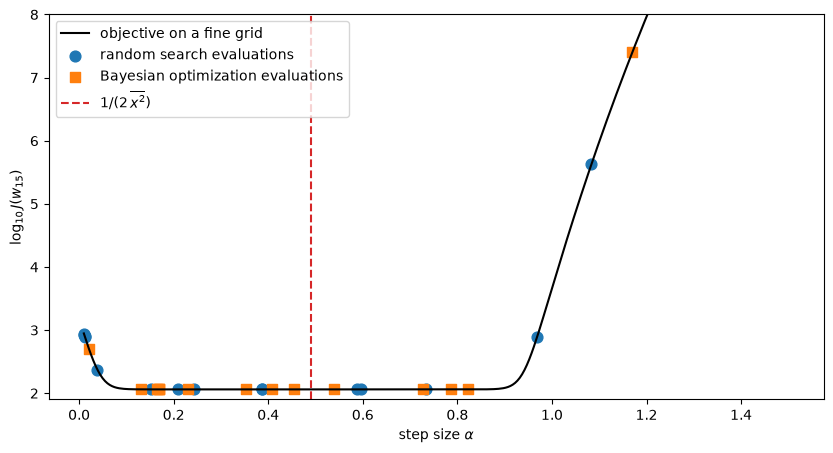

In [21]:
def objective(step_size, n_steps=15, w0=80.0):
    """log10 of the cost after n_steps of gradient descent from w0 with the given step size."""
    w_final = gradient_descent(w0, step_size, n_steps)[-1]
    return np.log10(mse(w_final)) if np.isfinite(w_final) else 30.0


alpha_grid = np.linspace(0.01, 1.5, 300)
f_grid = np.array([objective(a) for a in alpha_grid])
alpha_best_grid = alpha_grid[np.argmin(f_grid)]
print("(a) grid minimum near alpha = {:.3f}; analytic one-step value 1/(2 mean(x^2)) = {:.3f}; floor log10(J*) = {:.3f}".format(
    alpha_best_grid, 1 / (2 * mean_x2), np.log10(mse(wn))))

# (b) Random search: a step size lives on a log scale, so draw it log-uniformly
rng = np.random.default_rng(0)
random_alphas = loguniform(0.01, 1.5).rvs(size=15, random_state=rng)
random_values = np.array([objective(a) for a in random_alphas])
alpha_random = random_alphas[np.argmin(random_values)]

# (c) Bayesian optimization with a lower confidence bound, same budget of 15 evaluations
gp = GaussianProcessRegressor(kernel=C(3.0) * RBF(0.3), alpha=1e-6, optimizer=None)
bo_alphas = list(loguniform(0.01, 1.5).rvs(size=3, random_state=np.random.default_rng(1)))
bo_values = [objective(a) for a in bo_alphas]
candidates = alpha_grid[:, None]
for _ in range(12):
    gp.fit(np.array(bo_alphas)[:, None], bo_values)
    mean, std = gp.predict(candidates, return_std=True)
    next_alpha = float(candidates[np.argmin(mean - 1.96 * std), 0])
    bo_alphas.append(next_alpha)
    bo_values.append(objective(next_alpha))
alpha_bo = bo_alphas[int(np.argmin(bo_values))]
print("(b) random search best alpha = {:.3f} (objective {:.3f})".format(alpha_random, np.min(random_values)))
print("(c) Bayesian optimization best alpha = {:.3f} (objective {:.3f})".format(alpha_bo, np.min(bo_values)))

plt.figure(figsize=(10, 5))
plt.plot(alpha_grid, f_grid, 'k-', label='objective on a fine grid')
plt.scatter(random_alphas, random_values, s=60, label='random search evaluations')
plt.scatter(bo_alphas, bo_values, s=60, marker='s', label='Bayesian optimization evaluations')
plt.axvline(1 / (2 * mean_x2), color='C3', linestyle='--', label=r'$1/(2\,\overline{x^2})$')
plt.ylim(1.9, 8)
plt.xlabel(r'step size $\alpha$')
plt.ylabel(r'$\log_{10} J(w_{15})$')
plt.legend()
plt.show()

**(a)** The objective has a wide, flat floor: any step size with $|1 - \alpha\lambda|$ comfortably below one drives the error to the noise floor $\log_{10} J^*$ within 15 steps, so every $\alpha$ between roughly 0.15 and 0.85 looks equally good, with the exact centre at $1/\lambda = 1/(2\,\overline{x^2}) \approx 0.49$, where a single step would already land on the optimum. To the left the objective rises slowly (too many small steps); to the right of about $1/\overline{x^2} \approx 0.98$ it explodes, which is the divergence you saw in the first Experiment when you made the step size large. Tuning problems often look like this: a broad plateau of good values and a cliff, not a single sharp optimum.

**(b) and (c)** With 15 evaluations both methods land on the plateau. Bayesian optimization spends its first few picks probing the uncertain regions (including the cliff, once, which the lower confidence bound then avoids), and settles its later evaluations inside the plateau; random search relies on luck to land there, and with a log-uniform proposal a fair share of its draws is wasted on tiny step sizes. The difference is small on a one-dimensional problem whose good region covers a third of the range; it grows quickly with dimension and with narrower good regions.

**(d)** The extension over $(\alpha, \beta)$:

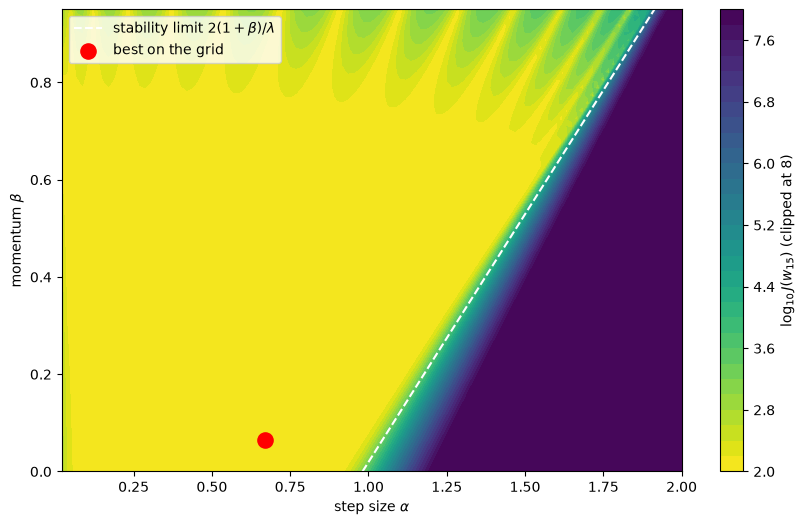

best on the grid: alpha = 0.669, beta = 0.06


In [22]:
def objective_momentum(step_size, beta, n_steps=15, w0=80.0):
    """log10 of the cost after n_steps of heavy-ball gradient descent."""
    w_final = gradient_descent_momentum(w0, step_size, beta, n_steps)[-1]
    return np.log10(mse(w_final)) if np.isfinite(w_final) else 30.0


alpha_axis = np.linspace(0.02, 2.0, 120)
beta_axis = np.linspace(0.0, 0.95, 60)
objective_map = np.array([[objective_momentum(a, b) for a in alpha_axis] for b in beta_axis])

plt.figure(figsize=(10, 6))
plt.contourf(alpha_axis, beta_axis, np.clip(objective_map, 2, 8), levels=30, cmap='viridis_r')
plt.colorbar(label=r'$\log_{10} J(w_{15})$ (clipped at 8)')
plt.plot(2 * (1 + beta_axis) / curvature, beta_axis, 'w--', label=r'stability limit $2(1+\beta)/\lambda$')
best = np.unravel_index(np.argmin(objective_map), objective_map.shape)
plt.scatter(alpha_axis[best[1]], beta_axis[best[0]], color='r', s=120, zorder=5, label='best on the grid')
plt.xlabel(r'step size $\alpha$')
plt.ylabel(r'momentum $\beta$')
plt.legend(loc='upper left')
plt.show()
print("best on the grid: alpha = {:.3f}, beta = {:.2f}".format(alpha_axis[best[1]], beta_axis[best[0]]))

The cliff moves to the right as $\beta$ grows, exactly along the stability limit $2(1 + \beta)/\lambda$ from the chapter's aside *Stability with Momentum*, so larger step sizes become usable with more momentum. Two things stop us from simply cranking both up. First, just left of the cliff at high $\beta$ the map shows stripes of poor values: there the iterates oscillate for longer than the 15 steps we allowed, so the extra stability buys nothing within our budget. Second, on this easy one-parameter problem 15 steps are plenty for almost any stable setting, so the floor is a wide plateau and the "best on the grid" marker is essentially arbitrary within it. The two hyperparameters are coupled through the stability line, which is why tuning them one at a time can mislead you: the right $\alpha$ depends on the $\beta$ you have chosen.